<a href="https://colab.research.google.com/github/gokul171EK/AI_ML_Specific_Models/blob/main/Hierarchical%20clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving USArrests.csv to USArrests.csv
DATASET LOADED SUCCESSFULLY
Rows    : 50
Columns : 5


,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6



Features used:
['Murder', 'Assault', 'UrbanPop', 'Rape']

Data standardized successfully!


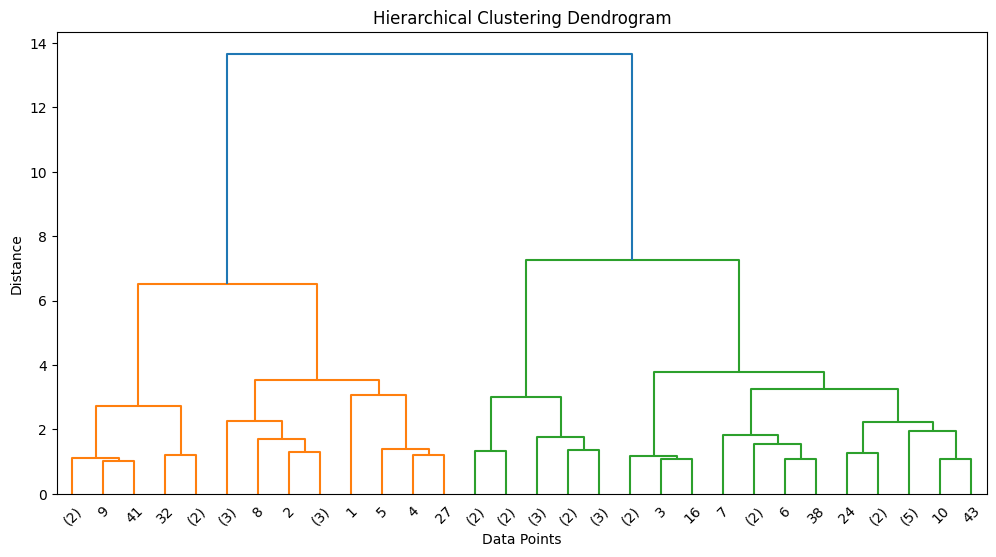


Cluster Distribution:
Cluster
0    19
1    19
2    12
Name: count, dtype: int64

Clustered Dataset:


,Unnamed: 0,Murder,Assault,UrbanPop,Rape,Cluster
0,Alabama,13.2,236,58,21.2,0
1,Alaska,10.0,263,48,44.5,0
2,Arizona,8.1,294,80,31.0,0
3,Arkansas,8.8,190,50,19.5,1
4,California,9.0,276,91,40.6,0
5,Colorado,7.9,204,78,38.7,0
6,Connecticut,3.3,110,77,11.1,1
7,Delaware,5.9,238,72,15.8,1
8,Florida,15.4,335,80,31.9,0
9,Georgia,17.4,211,60,25.8,0


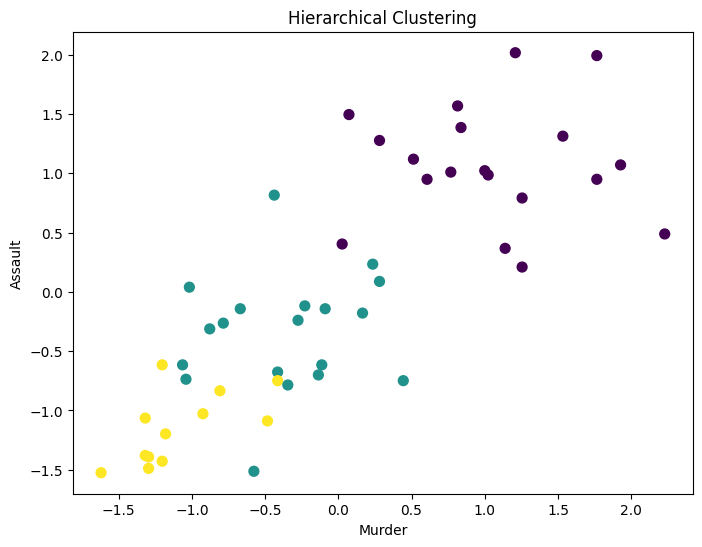


Cluster Summary:


,Murder,Assault,UrbanPop,Rape
Cluster,,,,
0,12.331579,259.315789,68.315789,29.215789
1,6.210526,142.052632,71.263158,19.184211
2,3.091667,76.000000,52.083333,11.833333



✅ HIERARCHICAL CLUSTERING COMPLETED
Output file: hierarchical_clustered_dataset.csv


In [1]:
# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


# ------------------------------------------------------------
# 1. Upload Dataset
# ------------------------------------------------------------

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())


# ------------------------------------------------------------
# 2. Select Numerical Features
# ------------------------------------------------------------

X = df.select_dtypes(include=np.number)

# Remove ID column if present
X = X.drop(columns=["StudentID"], errors="ignore")

print("\nFeatures used:")
print(X.columns.tolist())


# ------------------------------------------------------------
# 3. Handle Missing Values
# ------------------------------------------------------------

X = X.fillna(X.mean())


# ------------------------------------------------------------
# 4. Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nData standardized successfully!")


# ------------------------------------------------------------
# 5. Create Linkage
# ------------------------------------------------------------

linked = linkage(
    X_scaled,
    method="ward"
)


# ------------------------------------------------------------
# 6. Dendrogram
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Distance")

plt.show()


# ------------------------------------------------------------
# 7. Apply Hierarchical Clustering
# ------------------------------------------------------------

# Change according to dendrogram
n_clusters = 3

hierarchical = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage="ward"
)

clusters = hierarchical.fit_predict(X_scaled)


# ------------------------------------------------------------
# 8. Add Cluster Column
# ------------------------------------------------------------

df["Cluster"] = clusters


# ------------------------------------------------------------
# 9. Cluster Distribution
# ------------------------------------------------------------

print("\nCluster Distribution:")

print(df["Cluster"].value_counts())


# ------------------------------------------------------------
# 10. Display Clustered Dataset
# ------------------------------------------------------------

print("\nClustered Dataset:")

display(df.head(10))


# ------------------------------------------------------------
# 11. Visualization
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel(X.columns[0])

plt.ylabel(X.columns[1])

plt.title("Hierarchical Clustering")

plt.show()


# ------------------------------------------------------------
# 12. Cluster Summary
# ------------------------------------------------------------

cluster_summary = df.groupby("Cluster")[X.columns].mean()

print("\nCluster Summary:")

display(cluster_summary)


# ------------------------------------------------------------
# 13. Save Result
# ------------------------------------------------------------

df.to_csv(
    "hierarchical_clustered_dataset.csv",
    index=False
)

print("\n" + "=" * 60)
print("✅ HIERARCHICAL CLUSTERING COMPLETED")
print("=" * 60)

print("Output file: hierarchical_clustered_dataset.csv")